# PH Trend

In [28]:
import os
import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.basemap import Basemap
import geopandas as gpd
import requests  # kept because getEEZ supports GeoServer fallback

## Define User Input

In [29]:
# -------------------------
# USER CONFIG (pick one)
# -------------------------
REGION = "PACIFIC"  # options: "PACIFIC", "NRU", "NIU"

# FOOTER TEXT
TEXT_LEFT = "Nauru Meteorological Service (NMS) 2026"
TEXT_RIGHT = "Copernicus"
PLOT_TITLE = "Satellite PH Trends (1982–2024) — Pacific"

# EEZ Shapefile directory (relative to Codes/PH/)
EEZ_DIR = "../config/shapefiles/final_eez_country"
EEZ_FILES = {
    "PACIFIC": "PAC_EEZ_v3.zip",
    "NRU": "NRU.zip",
    "NIU": "NIU.zip",
}

# BBOXES in lon 0..360 (Pacific-centered convention for plotting)
BBOXES = {
    "PACIFIC": dict(west=100.0, east=300.0, south=-45.0, north=45.0),
    "NIU": dict(west=187.5, east=194.0, south=-22.9, north=-16.5),
    "NRU": dict(west=163.3, east=169.7, south=-4.0, north=2.8),
}

# Padding (degrees) around bbox only for country zooms
BBOX_PAD = dict(lon=2.0, lat=2.0)

## Read NetCDF

In [30]:
# -------------------------
# Read NetCDF
# -------------------------
ds = Dataset("https://ocean-thredds01.spc.int/thredds/dodsC/POP/PCC/ph_trend_data.nc", "r")
ph = ds.variables["ph_trend"][:]
lat = ds.variables["latitude"][:]
lon = ds.variables["longitude"][:]


## Subsetting and Data Selection

In [31]:
def getEEZ(ax, m, local_path=None, geojson_url=None, color="black", linewidth=1, linestyle="--"):
    """Plot EEZ boundaries from local file if available, otherwise from GeoServer URL."""
    gdf = None

    # Try reading from local file first, if provided
    if local_path is not None and os.path.exists(local_path):
        try:
            if local_path.endswith(".zip"):
                gdf = gpd.read_file(f"zip://{local_path}")
            else:
                gdf = gpd.read_file(local_path)
        except Exception as e:
            print(f"Failed to read local file {local_path}: {e}")

    # If no local data or failed, try GeoServer
    if gdf is None and geojson_url is not None:
        try:
            geojson_response = requests.get(geojson_url, timeout=60)
            if geojson_response.status_code == 200:
                geojson_data = geojson_response.json()
                gdf = gpd.GeoDataFrame.from_features(geojson_data["features"])
            else:
                print(
                    f"Failed to retrieve GeoJSON from {geojson_url} (HTTP {geojson_response.status_code})"
                )
        except Exception as e:
            print(f"Error fetching GeoJSON from {geojson_url}: {e}")

    if gdf is None:
        print("No EEZ data available to plot.")
        return

    # Ensure correct CRS
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326", allow_override=True)
    else:
        gdf = gdf.to_crs("EPSG:4326")

    # Plot boundaries (wrap lon to 0..360 so it matches your Pacific-centered map)
    for geom in gdf.geometry:
        if geom is None:
            continue
        if not geom.is_valid:
            geom = geom.buffer(0)

        def _plot_xy(x, y):
            x = np.asarray(x)
            x = np.where(x < 0, x + 360, x)
            if m is not None:
                xx, yy = m(x, y)
                ax.plot(xx, yy, color=color, linewidth=linewidth, linestyle=linestyle)
            else:
                ax.plot(x, y, color=color, linewidth=linewidth, linestyle=linestyle)

        if geom.geom_type == "LineString":
            x, y = geom.xy
            _plot_xy(x, y)
        elif geom.geom_type == "MultiLineString":
            for line in geom.geoms:
                x, y = line.xy
                _plot_xy(x, y)
        elif geom.geom_type == "Polygon":
            x, y = geom.exterior.xy
            _plot_xy(x, y)
        elif geom.geom_type == "MultiPolygon":
            for poly in geom.geoms:
                x, y = poly.exterior.xy
                _plot_xy(x, y)


def region_bbox(region: str):
    b = BBOXES[region].copy()
    if region in ("NRU", "NIU"):
        b["west"] -= BBOX_PAD["lon"]
        b["east"] += BBOX_PAD["lon"]
        b["south"] -= BBOX_PAD["lat"]
        b["north"] += BBOX_PAD["lat"]
    return b


def subset_to_bbox(lat, lon_wrapped, field2d, bbox):
    lat_mask = (lat >= bbox["south"]) & (lat <= bbox["north"])
    lon_mask = (lon_wrapped >= bbox["west"]) & (lon_wrapped <= bbox["east"])

    lat_sub = lat[lat_mask]
    lon_sub = lon_wrapped[lon_mask]
    field_sub = field2d[lat_mask, :][:, lon_mask]

    lon2d, lat2d = np.meshgrid(lon_sub, lat_sub)
    return lon2d, lat2d, field_sub


# -------------------------
# Resolve region settings
# -------------------------
if REGION not in EEZ_FILES:
    raise ValueError(f"Unknown REGION={REGION}. Use one of: {list(EEZ_FILES.keys())}")

bbox = region_bbox(REGION)
eez_zip_path = os.path.join(EEZ_DIR, EEZ_FILES[REGION])

## Plot

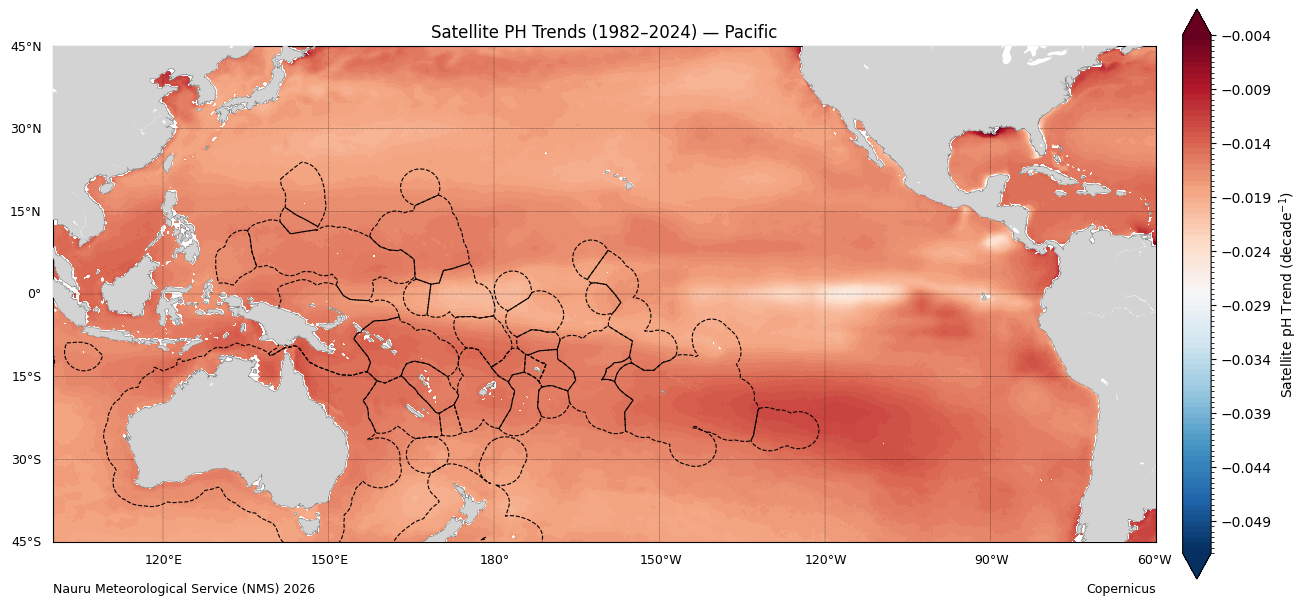

In [32]:
# -------------------------
# Prepare data
# -------------------------
# Replace fill values with masked values
fill_value = getattr(ds.variables["ph_trend"], "_FillValue", None)
if fill_value is not None:
    ph = np.ma.masked_where(ph == fill_value, ph)

# Convert longitude from 0-360 to -180..180
lon = np.where(lon > 180, lon - 360, lon)

# Sort longitudes and reorder accordingly
lon_sort = np.argsort(lon)
lon = lon[lon_sort]
ph = ph[:, lon_sort] * 10  # year-1 → decade-1

# Wrap lon to 0..360 for plotting/subsetting in Pacific-centered convention
lon_wrapped = np.where(lon < 0, lon + 360, lon)

# Sort wrapped longitudes and reorder accordingly
wrap_sort = np.argsort(lon_wrapped)
lon_wrapped = lon_wrapped[wrap_sort]
ph = ph[:, wrap_sort]

# Subset to selected bbox
lon2d, lat2d, ph_sub = subset_to_bbox(lat, lon_wrapped, ph, bbox)

# Levels / colormap
levels = np.arange(-0.052, -0.0037, 0.0005)
cmap = plt.get_cmap("RdBu_r")
norm = BoundaryNorm(levels, cmap.N)

# -------------------------
# Plot
# -------------------------
fig = plt.figure(figsize=(14, 6))
ax = plt.gca()

m = Basemap(
    projection="cyl",
    llcrnrlon=bbox["west"],
    urcrnrlon=bbox["east"],
    llcrnrlat=bbox["south"],
    urcrnrlat=bbox["north"],
    resolution="l",
    ax=ax,
 )

cf = m.contourf(
    lon2d, lat2d, ph_sub,
    levels=levels, cmap=cmap, norm=norm,
    extend="both", latlon=True
 )

m.drawcoastlines(color="grey", linewidth=0.8)
m.fillcontinents(color="lightgrey", lake_color="white", zorder=10)

# Gridlines: PACIFIC uses broader spacing; country zoom uses finer spacing
if REGION == "PACIFIC":
    par_step = 15
    mer_step = 30
else:
    par_step = 5
    mer_step = 5

par_start = np.floor(bbox["south"] / par_step) * par_step
par_end   = np.ceil(bbox["north"] / par_step) * par_step
mer_start = np.floor(bbox["west"] / mer_step) * mer_step
mer_end   = np.ceil(bbox["east"] / mer_step) * mer_step

m.drawparallels(np.arange(par_start, par_end + 0.1, par_step),
                labels=[1, 0, 0, 0], fontsize=9, linewidth=0.3, dashes=[1, 1])
m.drawmeridians(np.arange(mer_start, mer_end + 0.1, mer_step),
                labels=[0, 0, 0, 1], fontsize=9, linewidth=0.3, dashes=[1, 1])

cbar = plt.colorbar(cf, pad=0.02)
cbar.set_label("Satellite pH Trend (decade$^{-1}$)")
plt.title(PLOT_TITLE)

# EEZ on top (last)
getEEZ(ax=ax, m=m, local_path=eez_zip_path, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()

# Put footer relative to the axes (tracks bbox/plot size)
ax.text(0.0, -0.08, TEXT_LEFT,
        transform=ax.transAxes, ha="left", va="top",
        fontsize=9, color="black", clip_on=False)

ax.text(1.0, -0.08, TEXT_RIGHT,
        transform=ax.transAxes, ha="right", va="top",
        fontsize=9, color="black", clip_on=False)
plt.show()

ds.close()